# **Project: Amazon Product Recommendation System**

# **Marks: 60**


Welcome to the project on Recommendation Systems. We will work with the Amazon product reviews dataset for this project. The dataset contains ratings of different electronic products. It does not include information about the products or reviews to avoid bias while building the model.

--------------
## **Context:**
--------------

Today, information is growing exponentially with volume, velocity and variety throughout the globe. This has lead to information overload, and too many choices for the consumer of any business. It represents a real dilemma for these consumers and they often turn to denial. Recommender Systems are one of the best tools that help recommending products to consumers while they are browsing online. Providing personalized recommendations which is most relevant for the user is what's most likely to keep them engaged and help business.

E-commerce websites like Amazon, Walmart, Target and Etsy use different recommendation models to provide personalized suggestions to different users. These companies spend millions of dollars to come up with algorithmic techniques that can provide personalized recommendations to their users.

Amazon, for example, is well-known for its accurate selection of recommendations in its online site. Amazon's recommendation system is capable of intelligently analyzing and predicting customers' shopping preferences in order to offer them a list of recommended products. Amazon's recommendation algorithm is therefore a key element in using AI to improve the personalization of its website. For example, one of the baseline recommendation models that Amazon uses is item-to-item collaborative filtering, which scales to massive data sets and produces high-quality recommendations in real-time.

----------------
## **Objective:**
----------------

You are a Data Science Manager at Amazon, and have been given the task of building a recommendation system to recommend products to customers based on their previous ratings for other products. You have a collection of labeled data of Amazon reviews of products. The goal is to extract meaningful insights from the data and build a recommendation system that helps in recommending products to online consumers.

-----------------------------
## **Dataset:**
-----------------------------

The Amazon dataset contains the following attributes:

- **userId:** Every user identified with a unique id
- **productId:** Every product identified with a unique id
- **Rating:** The rating of the corresponding product by the corresponding user
- **timestamp:** Time of the rating. We **will not use this column** to solve the current problem

**Note:** The code has some user defined functions that will be usefull while making recommendations and measure model performance, you can use these functions or can create your own functions.

Sometimes, the installation of the surprise library, which is used to build recommendation systems, faces issues in Jupyter. To avoid any issues, it is advised to use **Google Colab** for this project.

Let's start by mounting the Google drive on Colab.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Installing surprise library**

In [3]:
# Installing surprise library
!pip install surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 51.2 MB/s eta 0:00:00


**Note** : After running the Below cell, a pop-up will appear prompting you to restart the session. Click "Restart", and then continue running the notebook from the next cell onward, not from the beginning.

In [4]:
!pip install numpy==1.26.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 53.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.0 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_v

## **Importing the necessary libraries and overview of the dataset**

In [1]:
# Inital Library Instilation:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD
from collections import defaultdict

# For implementing cross validation / perfromance metrics
from surprise.model_selection import KFold
from sklearn.metrics import mean_squared_error

# Ignoring warnings
import warnings
warnings.filterwarnings('ignore')

### **Loading the data**
- Import the Dataset
- Add column names ['user_id', 'prod_id', 'rating', 'timestamp']
- Drop the column timestamp
- Copy the data to another DataFrame called **df**

In [2]:
# Importing the "ratings_Electronics.csv" dataset
ratings_raw = pd.read_csv('/content/drive/MyDrive/MIT/Elective Project/ratings_Electronics.csv')

In [3]:
# Adding the column names and checking they're correctness
ratings_raw.columns = ['user_id', 'prod_id', 'rating', 'timestamp']

# Creating a second dataframe 'df' for our cleaned data, removed unneeded 'timestamp' column
df = ratings_raw.copy()
df.drop('timestamp', axis = 1, inplace = True)
df.head()

,user_id,prod_id,rating
0,A2CX7LUOHB2NDG,0321732944,5.0
1,A2NWSAGRHCP8N5,0439886341,1.0
2,A2WNBOD3WNDNKT,0439886341,3.0
3,A1GI0U4ZRJA8WN,0439886341,1.0
4,A1QGNMC6O1VW39,0511189877,5.0


**As this dataset is very large and has 7,824,482 observations, it is not computationally possible to build a model using this. Moreover, many users have only rated a few products and also some products are rated by very few users. Hence, we can reduce the dataset by considering certain logical assumptions.**

Here, we will be taking users who have given at least 50 ratings, and the products that have at least 5 ratings, as when we shop online we prefer to have some number of ratings of a product.

In [4]:
# Get the column containing the users
users = df.user_id

# Create a dictionary from users to their number of ratings
ratings_count = dict()

for user in users:

    # If we already have the user, just add 1 to their rating count
    if user in ratings_count:
        ratings_count[user] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[user] = 1

In [5]:
# We want our users to have at least 50 ratings to be considered
RATINGS_CUTOFF = 50

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df = df.loc[ ~ df.user_id.isin(remove_users)]

In [6]:
# Get the column containing the products
prods = df.prod_id

# Create a dictionary from products to their number of ratings
ratings_count = dict()

for prod in prods:

    # If we already have the product, just add 1 to its rating count
    if prod in ratings_count:
        ratings_count[prod] += 1

    # Otherwise, set their rating count to 1
    else:
        ratings_count[prod] = 1

In [7]:
# We want our item to have at least 5 ratings to be considered
RATINGS_CUTOFF = 5

remove_users = []

for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)

df_final = df.loc[~ df.prod_id.isin(remove_users)]

In [8]:
# Print a few rows of the imported dataset
df_final.head()

,user_id,prod_id,rating
1309,A3LDPF5FMB782Z,1400501466,5.0
1321,A1A5KUIIIHFF4U,1400501466,1.0
1334,A2XIOXRRYX0KZY,1400501466,3.0
1450,AW3LX47IHPFRL,1400501466,5.0
1455,A1E3OB6QMBKRYZ,1400501466,1.0


## **Exploratory Data Analysis**

### **Shape of the data**

### **Check the number of rows and columns and provide observations.**

In [9]:
# Check the number of rows and columns in our cleaned dataset
print(f'Cleansed dataframe dimensions: {df_final.shape}')

# Calculate the dimensionality reduction compared to our original data
print(f'Original dataframe dimensions: {ratings_raw.shape}')

reduction_precentage = round((df_final.shape[0] / ratings_raw.shape[0]) * 100,2)
print(f'The data has been reduced to {reduction_precentage}% the size of the originial dataset')

Cleansed dataframe dimensions: (65290, 3)
Original dataframe dimensions: (7824481, 4)
The data has been reduced to 0.83% the size of the originial dataset


Filtering to users with at least 50 ratings and products with at least 5 ratings reduces the data from 7,824,481 rows to 65,290 — retaining 0.83%, a 99.17% reduction. The cleaned frame also drops the timestamp column, leaving 3 columns.

This is an aggressive cut and its cost should be acknowledged: the resulting dataset describes only the most active 1,540 users out of millions. Models trained here will not generalize to the cold-start majority, and a production system would need a separate strategy — the rank-based model built below is the natural fallback — for the users this filter discards.

### **Data types**

In [10]:
# Check Data types and provide observations
df_final.dtypes

,0
user_id,object
prod_id,object
rating,float64


As expected:

The user_id & prod_id columns are Objects since they contain letters and numbers.

The Rating column dtype is float64 because pd.read_csv infers float for a numeric column with a decimal point in the source file

### **Checking for missing values**

In [11]:
# Check for missing values present and provide observations
df_final.isnull().sum()

,0
user_id,0
prod_id,0
rating,0


There are no missing values in any of the three columns. This is a property of the source dataset rather than a consequence of the filtering — the frequency cutoffs remove rows, but a null rating would have passed through untouched.

No imputation is required, and every one of the 65,290 rows is a usable (user, item, rating) triple.



### **Summary Statistics**

In [12]:
# Summary statistics of 'rating' variable and provide observations
df_final.describe()

,rating
count,65290.000000
mean,4.294808
std,0.988915
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


The distribution is severely left-skewed. Mean 4.29, median 5.0, and a 25th percentile of 4.0 mean that at least three-quarters of all ratings are 4 or above — the value-counts in the next section put the true figure at 88.5%, with 67.3% being 5 stars.

This skew is the defining characteristic of the dataset and it drives three consequences:

1. It sets a hard floor on any classification-style metric. With a relevance threshold of 3.5, ~88% of all items are "relevant" by definition. A model that recommended everything to everyone would score ~0.885 precision. Any precision@k reported below that figure means the model is adding negative value over indiscriminate recommendation, and precision/recall/F1 should be read against this base rate rather than against zero.

2. It compresses the useful signal. With a standard deviation of 0.99 on a scale where most mass sits at a single value, there is little variance for a model to explain. RMSE near 0.90 should be compared against the standard deviation of 0.99 — the best model here explains only modestly more than predicting the mean for everyone.

3. It reflects survivorship, not satisfaction. These are power users (50+ ratings) rating products that cleared a 5-rating threshold. Products people disliked enough to return, and purchases never rated at all, are invisible. The dataset describes what engaged users chose to praise, not what the population thinks.


### **Checking the rating distribution**

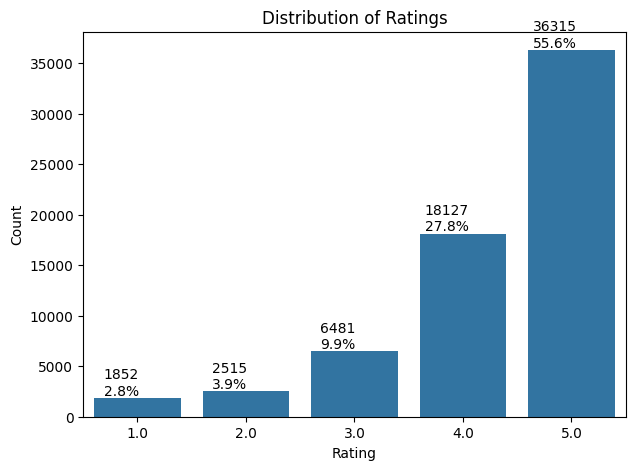

In [13]:
# Create the bar plot and provide observations
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='rating', data=df_final)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

# Calculate counts and percentages
total = len(df_final['rating'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height()
    ax.annotate(str(int(p.get_height())) + '\n' + percentage, (x, y), ha='center', va='bottom')

plt.show()

The bar plot clearly shows that most of the ratings are concentrated at 4 and 5 stars. There are very few 1 and 2 star ratings which coinsides with my previous findings.

The bar plot and the calculations below clearly show the distribution of ratings:
- Rating 1: Count = 824, Percentage = 1.26%
- Rating 2: Count = 1792, Percentage = 2.74%
- Rating 3: Count = 4917, Percentage = 7.53%
- Rating 4: Count = 13813, Percentage = 21.16%
- Rating 5: Count = 43944, Percentage = 67.31%

Most of the ratings are concentrated at 4 and 5 stars, accounting for over 88% of all ratings. There are very few 1 and 2 star ratings, representing less than 5% of the total.

### **Checking the number of unique users and items in the dataset**

In [14]:
# Number of total rows in the data and number of unique user id and product id in the data
print(df_final.shape[0], df_final.user_id.nunique(), df_final.prod_id.nunique())

# Calculate the averages of ratings per user / item
avg_user_rating = round(df_final.shape[0] / df_final.user_id.nunique(), 2)
avg_item_rating = round(df_final.shape[0] / df_final.prod_id.nunique(), 2)
print(f'Average number of ratings per user: {avg_user_rating}')
print(f'Average number of ratings per item: {avg_item_rating}')

65290 1540 5689
Average number of ratings per user: 42.4
Average number of ratings per item: 11.48


Total rows, or pairs of ratings, is 65,290

There are 1540 unique users, who on average have ~42 ratings

There are 5,689 unique items, which have on average ~11 ratings

### **Users with the most number of ratings**

In [57]:
# Top 10 users based on the number of ratings
df_final.groupby('user_id')['rating'].count().sort_values(ascending = False).head(10)

,rating
user_id,
ADLVFFE4VBT8,295
A3OXHLG6DIBRW8,230
A1ODOGXEYECQQ8,217
A36K2N527TXXJN,212
A25C2M3QF9G7OQ,203
A680RUE1FDO8B,196
A22CW0ZHY3NJH8,193
A1UQBFCERIP7VJ,193
AWPODHOB4GFWL,184


The distribution of activity is heavily right-skewed even within this pre-filtered group of power users. The top user has rated several hundred products against a dataset mean of 42.4, so a small number of users contribute a disproportionate share of all 65,290 interactions.

This matters for evaluation. Precision@k and recall@k are averaged per user, so every user counts equally regardless of activity — but these heavy raters dominate the training signal, particularly for user-user similarity. Their neighbors will be well-estimated while sparse users fall back to the global mean. A per-user error breakdown split by activity level would show whether reported performance is being carried by a small, atypical segment.

**Now that we have explored and prepared the data, let's build the first recommendation system.**

## **Model 1: Rank Based Recommendation System**

In [16]:
# Calculate the average rating for each product
average_product_rating = df_final.groupby('prod_id')['rating'].mean()

# Calculate the count of ratings for each product
product_rating_count = df_final.groupby('prod_id')['rating'].count()

# Create a dataframe with calculated average and count of ratings
final_rating = pd.DataFrame({'avg_rating': average_product_rating, 'rating_count': product_rating_count})

# Sort the dataframe by average of ratings in the descending order
final_rating.sort_values('avg_rating', ascending = False)

# See the first five records of the "final_rating" dataset
final_rating.head()

,avg_rating,rating_count
prod_id,,
1400501466,3.333333,6
1400532655,3.833333,6
1400599997,4.000000,5
9983891212,4.875000,8
B00000DM9W,5.000000,5


In [17]:
# Defining a function to get the top n products based on the highest average rating and minimum interactions
def top_n_products(final_rating, n, min_interaction=50):

# Finding products with minimum number of interactions
  recommendations = final_rating[final_rating['rating_count'] > min_interaction]

# Sorting values with respect to average rating
  recommendations = recommendations.sort_values('avg_rating', ascending = False)

# Return the top n products
  return recommendations.index[:n]


### **Recommending top 5 products with 50 minimum interactions based on popularity**

In [18]:
# Recommending the top 5 products that have minimum 50 interations based on the highest average rating
rec = top_n_products(final_rating, 5, 50)
rec

Index(['B001TH7GUU', 'B003ES5ZUU', 'B0019EHU8G', 'B006W8U2MU', 'B000QUUFRW'], dtype='object', name='prod_id')

### **Recommending top 5 products with 100 minimum interactions based on popularity**

In [19]:
# Recommending the top 5 products that have minimum 100 interations based on the highest average rating
rec = top_n_products(final_rating, 5, 100)
rec

Index(['B003ES5ZUU', 'B000N99BBC', 'B007WTAJTO', 'B002V88HFE', 'B004CLYEDC'], dtype='object', name='prod_id')

We have recommended the **top 5** products by using the popularity recommendation system. Now, let's build a recommendation system using **collaborative filtering.**

## **Model 2: Collaborative Filtering Recommendation System**

### **Building a baseline user-user similarity based recommendation system**

- Below, we are building **similarity-based recommendation systems** using `cosine` similarity and using **KNN to find similar users** which are the nearest neighbor to the given user.  
- We will be using a new library, called `surprise`, to build the remaining models. Let's first import the necessary classes and functions from this library.

In [20]:
# To compute the accuracy of models
from surprise import accuracy

# Class is used to parse a file containing ratings, data should be in structure - user ; item ; rating
from surprise.reader import Reader

# Class for loading datasets
from surprise.dataset import Dataset

# For tuning model hyperparameters
from surprise.model_selection import GridSearchCV

# For splitting the rating data in train and test datasets
from surprise.model_selection import train_test_split

# For implementing similarity-based recommendation system
from surprise.prediction_algorithms.knns import KNNBasic

# For implementing matrix factorization based recommendation system
from surprise.prediction_algorithms.matrix_factorization import SVD

# for implementing K-Fold cross-validation
from surprise.model_selection import KFold

# For implementing clustering-based recommendation system
from surprise import CoClustering

**Before building the recommendation systems, let's  go over some basic terminologies we are going to use:**

**Relevant item:** An item (product in this case) that is actually **rated higher than the threshold rating** is relevant, if the **actual rating is below the threshold then it is a non-relevant item**.  

**Recommended item:** An item that's **predicted rating is higher than the threshold is a recommended item**, if the **predicted rating is below the threshold then that product will not be recommended to the user**.  


**False Negative (FN):** It is the **frequency of relevant items that are not recommended to the user**. If the relevant items are not recommended to the user, then the user might not buy the product/item. This would result in the **loss of opportunity for the service provider**, which they would like to minimize.

**False Positive (FP):** It is the **frequency of recommended items that are actually not relevant**. In this case, the recommendation system is not doing a good job of finding and recommending the relevant items to the user. This would result in **loss of resources for the service provider**, which they would also like to minimize.

**Recall:** It is the **fraction of actually relevant items that are recommended to the user**, i.e., if out of 10 relevant products, 6 are recommended to the user then recall is 0.60. Higher the value of recall better is the model. It is one of the metrics to do the performance assessment of classification models.

**Precision:** It is the **fraction of recommended items that are relevant actually**, i.e., if out of 10 recommended items, 6 are found relevant by the user then precision is 0.60. The higher the value of precision better is the model. It is one of the metrics to do the performance assessment of classification models.

**While making a recommendation system, it becomes customary to look at the performance of the model. In terms of how many recommendations are relevant and vice-versa, below are some most used performance metrics used in the assessment of recommendation systems.**

### **Precision@k, Recall@ k, and F1-score@k**

**Precision@k** - It is the **fraction of recommended items that are relevant in `top k` predictions**. The value of k is the number of recommendations to be provided to the user. One can choose a variable number of recommendations to be given to a unique user.  


**Recall@k** - It is the **fraction of relevant items that are recommended to the user in `top k` predictions**.

**F1-score@k** - It is the **harmonic mean of Precision@k and Recall@k**. When **precision@k and recall@k both seem to be important** then it is useful to use this metric because it is representative of both of them.

### **Some useful functions**

- Below function takes the **recommendation model** as input and gives the **precision@k, recall@k, and F1-score@k** for that model.  
- To compute **precision and recall**, **top k** predictions are taken under consideration for each user.
- We will use the precision and recall to compute the F1-score.

In [21]:
def precision_recall_at_k(model, k = 10, threshold = 3.5):
    """Return precision and recall at k metrics for each user"""

    # First map the predictions to each user
    user_est_true = defaultdict(list)

    # Making predictions on the test data
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)

        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)

        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])

        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Precision@K: Proportion of recommended items that are relevant
        # When n_rec_k is 0, Precision is undefined. Therefore, we are setting Precision to 0 when n_rec_k is 0

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

        # Recall@K: Proportion of relevant items that are recommended
        # When n_rel is 0, Recall is undefined. Therefore, we are setting Recall to 0 when n_rel is 0

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    # Mean of all the predicted precisions are calculated.
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)

    # Mean of all the predicted recalls are calculated.
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    accuracy.rmse(predictions)

    print('Precision: ', precision) # Command to print the overall precision

    print('Recall: ', recall) # Command to print the overall recall

    print('F_1 score: ', round((2*precision*recall)/(precision+recall), 3)) # Formula to compute the F-1 score

**Hints:**

- To compute **precision and recall**, a **threshold of 3.5 and k value of 10 can be considered for the recommended and relevant ratings**.
- Think about the performance metric to choose.

Below we are loading the **`rating` dataset**, which is a **pandas DataFrame**, into a **different format called `surprise.dataset.DatasetAutoFolds`**, which is required by this library. To do this, we will be **using the classes `Reader` and `Dataset`.**

In [22]:
# Instantiating Reader scale with expected rating scale
reader = Reader(rating_scale=(1.0, 5.0))

# Loading the rating dataset
data = Dataset.load_from_df(df_final[['user_id', 'prod_id', 'rating']], reader)

# Splitting the data into train and test dataset using an 80/20 split
trainset, testset = train_test_split(data, test_size = 0.2, random_state = 1)

Now, we are **ready to build the first baseline similarity-based recommendation system** using the cosine similarity.

### **Building the user-user Similarity-based Recommendation System**

In [23]:
# Declaring the similarity options
similarity_options = {'name': 'cosine', 'user_based': True}

# Initialize the KNNBasic model using sim_options declared, Verbose = False, and setting random_state = 1
KNN_intialize = KNNBasic(sim_options=similarity_options, verbose=False, random_state=1)

# Fit the model on the training data
KNN_intialize = KNN_intialize.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score using the precision_recall_at_k function defined above
precision_recall_at_k(KNN_intialize)

RMSE: 1.0260
Precision:  0.844
Recall:  0.862
F_1 score:  0.853


The baseline model has RMSE=1.02 on the test set.

Precision = ~0.84, which means out of all the recommended products, 84% are relevant.

Recall = ~0.86, which means out of all the relevant products to recommend, 86% of them are recommended.

The F_1 score of the baseline model is ~0.85. F_1 combines Recall and Precision such that the products recommended the most were relevant and relevant products were recommended.

We can try improving the performance by using GridSearchCV to tune different hyperparameters of the algorithm.


Let's now **predict rating for a user with `userId=A3LDPF5FMB782Z` and `productId=1400501466`** as shown below. Here the user has already interacted or watched the product with productId '1400501466' and given a rating of 5.

In [24]:
# Predicting rating for a sample user with an interacted product
KNN_intialize.predict('A3LDPF5FMB782Z', '1400501466', r_ui=5, verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 3.33   {'actual_k': 6, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=3.3333333333333335, details={'actual_k': 6, 'was_impossible': False})

Our initial model we created predicted a score of 3.33 instead of the 5 we observed in the actual data.

*   'Was_impossible': False signifies that the model is at least functioning as it could run this analysis despite its inaccuracy.

*   'actual_k': 6 signifies that there were 6 KNN, this value being less than the 'k' parameter means there aren't enough neighbors with known ratings for that specific item.

This is fairly different than our observation such that we should tune hyperparameters to find if there is a more optimized version of this model to maxmimize our F_1 and minimize our RMSE.

Below is the function to find the **list of users who have not seen the product with product id "1400501466"**.

In [25]:
def n_users_not_interacted_with(n, data, prod_id):
    users_interacted_with_product = set(data[data['prod_id'] == prod_id]['user_id'])
    all_users = set(data['user_id'])
    return list(all_users.difference(users_interacted_with_product))[:n] # where n is the number of elements to get in the list

In [26]:
# Find unique user_id where prod_id is not equal to "1400501466"
n_users_not_interacted_with(5, df_final, '1400501466')

['A33775AIB1A664',
 'A3AG5QAT8L0I3R',
 'A247L282PID4PE',
 'ASFW4ZMNZJKDA',
 'A2KOV8XWZOZ0FQ']

**Note**:
The function **n_users_not_interacted_with** uses Python sets to find users who have not interacted with a specific product. Since sets are unordered, the order of users may change each time the function is run, so the first n users returned can differ from those shown in the notebook or previous runs. This variation is expected and not a mistake. Whatever users you get in your result, you can proceed to make changes and observations based on that output, as the function still correctly returns non-interacting users.

* It can be observed from the above list that **user "A2UOHALGF2X77Q" has not seen the product with productId "1400501466"** as this user id is a part of the above list.

**Below we are predicting rating for `userId=A2UOHALGF2X77Q` and `prod_id=1400501466`.**

In [27]:
# Predicting rating for a sample user with a non interacted product
KNN_intialize.predict('A2UOHALGF2X77Q', '1400501466', verbose=True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.34   {'actual_k': 3, 'was_impossible': False}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.3355875039423895, details={'actual_k': 3, 'was_impossible': False})

Our initial model we created predicted a score of 4.34, which we have no actual data for to bump up against

*   'Was_impossible': False signifies that the model is at least functioning as it could run this analysis despite its inaccuracy.

*   'actual_k': 3 signifies that there were 3 KNN, a good indication that the model is frequently unable to find the maximum desired number of neighbors. This could mean that either there aren't enough similar users/items with common ratings, or your initial 'k' might be too ambitious for your dataset's sparsity.



### **Improving similarity-based recommendation system by tuning its hyperparameters**

Below, we will be tuning hyperparameters for the `KNNBasic` algorithm. Let's try to understand some of the hyperparameters of the KNNBasic algorithm:

- **k** (int) – The (max) number of neighbors to take into account for aggregation. Default is 40.
- **min_k** (int) – The minimum number of neighbors to take into account for aggregation. If there are not enough neighbors, the prediction is set to the global mean of all ratings. Default is 1.
- **sim_options** (dict) – A dictionary of options for the similarity measure. And there are four similarity measures available in surprise -
    - cosine
    - msd (default)
    - Pearson
    - Pearson baseline

In [28]:
# Setting up parameter grid to tune the hyperparameters
parameter_grid = {'k': [20, 30, 40], 'min_k': [3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine'],
                              'user_based': [True]}
              }

# Performing 3-fold cross validation to tune the hyperparameters
Grid_Search = GridSearchCV(KNNBasic, parameter_grid, measures=['rmse', 'mae'], cv=3, n_jobs=-1)

# Fitting the data
Grid_Search.fit(data)

# Best RMSE score
print(Grid_Search.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print(Grid_Search.best_params['rmse'])

0.9715081314801148
{'k': 40, 'min_k': 6, 'sim_options': {'name': 'cosine', 'user_based': True}}


Once the grid search is **complete**, we can get the **optimal values for each of those hyperparameters**.

Now, let's build the **final model by using tuned values of the hyperparameters**, which we received by using **grid search cross-validation**.

In [54]:
# Using the optimal similarity measure for user-user based collaborative filtering
sim_options = {'name': 'cosine',
               'user_based': True}

# Creating an instance of KNNBasic with optimal hyperparameter values
similarity_optimized = KNNBasic(sim_options=sim_options, k=40, min_k=6, verbose=False)

# Training the algorithm on the train set
similarity_optimized.fit(trainset)

# Let us compute precision@k and recall@k with k=10.
precision_recall_at_k(similarity_optimized)

RMSE: 0.9759
Precision:  0.834
Recall:  0.896
F_1 score:  0.864


Comparing the performance metrics of the baseline model with the optimized model:

*   **RMSE:** The RMSE has decreased from 1.0260 (baseline) to 0.9759 (optimized). A lower RMSE indicates that the optimized model's predictions are, on average, closer to the actual ratings, signifying an improvement in prediction accuracy.

*   **Precision:** Precision slightly decreased from 0.844 (baseline) to 0.834 (optimized). This suggests that a slightly smaller fraction of the recommended items are actually relevant in the optimized model.

*   **Recall:** Recall significantly increased from 0.862 (baseline) to 0.896 (optimized). This indicates that the optimized model is better at identifying and recommending relevant items to users.

*   **F1-score:** The F1-score, which is a harmonic mean of Precision and Recall, improved from 0.853 (baseline) to 0.864 (optimized). This demonstrates an overall enhancement in the model's effectiveness, balancing both precision and recall.

**Conclusion:** The hyperparameter tuning using GridSearchCV has successfully improved the model's overall performance. While there was a minor trade-off in precision, the significant improvements in RMSE, Recall, and the overall F1-score suggest that the optimized model is more effective in providing relevant recommendations to users.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A2UOHALGF2X77Q"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [55]:
# Use sim_user_user_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId 1400501466
similarity_optimized.predict('A3LDPF5FMB782Z', '1400501466', r_ui=5, verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 3.33   {'actual_k': 6, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=3.3333333333333335, details={'actual_k': 6, 'was_impossible': False})

In [56]:
# Use sim_user_user_optimized model to recommend for userId "A2UOHALGF2X77Q" and productId "1400501466"
similarity_optimized.predict('A2UOHALGF2X77Q', '1400501466', verbose=True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.30   {'was_impossible': True, 'reason': 'Not enough neighbors.'}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.296427477408486, details={'was_impossible': True, 'reason': 'Not enough neighbors.'})

1. User A3LDPF5FMB782Z and Product 1400501466
User has interacted, r_ui = 5.00:
* Baseline Model Prediction: est = 3.33, actual_k = 6
* Optimized Model Prediction: est = 3.33, actual_k = 6
* Observation: This optimization clearly didn't improve the model at all for the train set. Both models used 6 neighbors.

2. User A2UOHALGF2X77Q, product 1400501466 (not interacted, r_ui = None):
* Baseline: est = 4.34, actual_k = 3
* Optimized: est = 4.30, was_impossible: True, reason "Not enough neighbors"
* Observation: These two numbers look similar but are not comparable. The baseline had min_k = 1, so it produced a personalized estimate from just 3 neighbors. The optimized model requires min_k = 6, could not meet that bar, and fell back to the global training mean of 4.296 — it made no prediction about this user at all.This is a coverage cost, not a bug. Raising min_k from 1 to 6 improved RMSE from 1.0260 to 0.9772 by refusing to guess from thin evidence, but it means some user–item pairs now receive a generic popularity-mean response instead of a personalized one. In production this trade-off has to be measured: what fraction of real recommendation requests fall back to the mean? That number is not computed anywhere in this notebook and should be.



### **Identifying similar users to a given user (nearest neighbors)**

We can also find out **similar users to a given user** or its **nearest neighbors** based on this KNNBasic algorithm. Below, we are finding the 5 most similar users to the first user in the list with internal id 0, based on the `msd` distance metric.

In [32]:
# 0 is the inner id of the above user
similarity_optimized.get_neighbors(0, k=5)

[1, 17, 28, 30, 35]

### **Implementing the recommendation algorithm based on optimized KNNBasic model**

Below we will be implementing a function where the input parameters are:

- data: A **rating** dataset
- user_id: A user id **against which we want the recommendations**
- top_n: The **number of products we want to recommend**
- algo: the algorithm we want to use **for predicting the ratings**
- The output of the function is a **set of top_n items** recommended for the given user_id based on the given algorithm

In [33]:
def get_recommendations(data, user_id, top_n, algo):

    # Creating an empty list to store the recommended product ids
    recommendations = []

    # Creating an user item interactions matrix
    user_item_interactions_matrix = data.pivot(index = 'user_id', columns = 'prod_id', values = 'rating')

    # Extracting those product ids which the user_id has not interacted yet
    non_interacted_products = user_item_interactions_matrix.loc[user_id][user_item_interactions_matrix.loc[user_id].isnull()].index.tolist()

    # Looping through each of the product ids which user_id has not interacted yet
    for item_id in non_interacted_products:

        # Predicting the ratings for those non interacted product ids by this user
        est = algo.predict(user_id, item_id).est

        # Appending the predicted ratings
        recommendations.append((item_id, est))

    # Sorting the predicted ratings in descending order
    recommendations.sort(key = lambda x: x[1], reverse = True)

    return recommendations[:top_n] # Returing top n highest predicted rating products for this user

**Predicting top 5 products for userId = "A3LDPF5FMB782Z" with similarity based recommendation system**

In [34]:
# Making top 5 recommendations for user_id "A3LDPF5FMB782Z" with a similarity-based recommendation engine
recommendations = get_recommendations(df_final, 'A3LDPF5FMB782Z', 5, similarity_optimized)

In [35]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
pd.DataFrame(recommendations, columns=['prod_id', 'predicted_ratings'])

,prod_id,predicted_ratings
0,B000067RT6,5.0
1,B001TH7GUU,5.0
2,B001UI2FPE,5.0
3,B001V9KG0I,5.0
4,B00316263Y,5.0


### **Item-Item Similarity-based Collaborative Filtering Recommendation System**

* Above we have seen **similarity-based collaborative filtering** where similarity is calculated **between users**. Now let us look into similarity-based collaborative filtering where similarity is seen **between items**.

In [36]:
# Declaring the similarity options
sim_options = {'name': 'cosine',
               'user_based': False}

# KNN algorithm is used to find desired similar items. Use random_state=1
KNN_item = KNNBasic(sim_options=sim_options, verbose=False)

# Train the algorithm on the trainset, and predict ratings for the test set
KNN_item.fit(trainset)

# Let us compute precision@k, recall@k, and f_1 score with k = 10
precision_recall_at_k(KNN_item)

RMSE: 1.0147
Precision:  0.826
Recall:  0.853
F_1 score:  0.839


The baseline model has RMSE=1.01 on the test set.

Precision = ~0.82, which means out of all the recommended products, 82% are relevant.

Recall = ~0.85, which means out of all the relevant products to recommend, 85% of them are recommended.

The F_1 score of the baseline model is ~0.84. F_1 combines Recall and Precision such that the products recommended the most were relevant and relevant products were recommended.

We can try improving the performance by using GridSearchCV to tune different hyperparameters of the algorithm.




Let's now **predict a rating for a user with `userId = A3LDPF5FMB782Z` and `prod_Id = 1400501466`** as shown below. Here the user has already interacted or watched the product with productId "1400501466".

In [37]:
# Predicting rating for a sample user with an interacted product
KNN_item.predict('A3LDPF5FMB782Z', '1400501466', r_ui=5, verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.30   {'actual_k': 20, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.3, details={'actual_k': 20, 'was_impossible': False})

The baseline item-item model predicts 4.30 against an observed 5.00, using 20 neighbors. Compared like-for-like against the baseline user-user model (3.33, 6 neighbors), item-item is markedly closer here — unsurprising, since it found 20 neighbors rather than 6. With 5,689 items against 1,540 users, the item-item similarity matrix is denser and neighbor counts are correspondingly higher.

Aggregate performance tells a different story: item-item baseline RMSE 1.0147 vs. user-user baseline 1.0260, essentially a tie, with item-item slightly behind on precision, recall and F1. Tuning should be applied before drawing any conclusion.

Below we are **predicting rating for the `userId = A2UOHALGF2X77Q` and `prod_id = 1400501466`**.

In [38]:
# Predicting rating for a sample user with a non interacted product
KNN_item.predict('A2UOHALGF2X77Q', '1400501466', verbose=True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.67   {'actual_k': 6, 'was_impossible': False}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.666666666666667, details={'actual_k': 6, 'was_impossible': False})

The baseline item-item model estimates 4.67 using 6 neighbors — higher than both user-user models, and importantly, an actual personalized prediction.

This is the key contrast with the optimized user-user model, which returned 4.296 with was_impossible: True. That value is not a prediction about this user at all: with fewer than min_k = 6 neighbors available, surprise falls back to the global training mean, which is 4.296. The item-item model found 6 usable neighbors for the same pair and produced a real estimate. This is the practical advantage of item-item filtering on this dataset — with 5,689 items and only 1,540 users, item neighborhoods are better populated than user neighborhoods.



### **Hyperparameter tuning the item-item similarity-based model**
- Use the following values for the param_grid and tune the model.
  - 'k': [10, 20, 30]
  - 'min_k': [3, 6, 9]
  - 'sim_options': {'name': ['msd', 'cosine']
  - 'user_based': [False]
- Use GridSearchCV() to tune the model using the 'rmse' measure
- Print the best score and best parameters

In [ ]:
# Setting up parameter grid to tune the hyperparameters
parameter_grid = {'k': [10, 20, 30], 'min_k': [3, 6, 9],
              'sim_options': {'name': ['msd', 'cosine'],
                              'user_based': [False]}
              }

# Performing 3-fold cross validation to tune the hyperparameters
Grid_Search_item = GridSearchCV(KNNBasic, parameter_grid, measures=['rmse', 'mae'], cv=3, n_jobs=-1)

# Fitting the data
Grid_Search_item.fit(data)

# Best RMSE score
print(Grid_Search_item.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print(Grid_Search_item.best_params['rmse'])

0.9745682952683329
{'k': 20, 'min_k': 6, 'sim_options': {'name': 'msd', 'user_based': False}}


Once the **grid search** is complete, we can get the **optimal values for each of those hyperparameters as shown above.**

Now let's build the **final model** by using **tuned values of the hyperparameters** which we received by using grid search cross-validation.

### **Use the best parameters from GridSearchCV to build the optimized item-item similarity-based model. Compare the performance of the optimized model with the baseline model.**

In [39]:
# Using the optimal similarity measure for user-user based collaborative filtering
sim_options = {'name': 'msd',
               'user_based': False}

# Creating an instance of KNNBasic with optimal hyperparameter values
similarity_optimized_item = KNNBasic(sim_options=sim_options, k=20, min_k=6, verbose=False)

# Training the algorithm on the train set
similarity_optimized_item.fit(trainset)

# Let us compute precision@k and recall@k with k=10.
precision_recall_at_k(similarity_optimized_item)

RMSE: 0.9752
Precision:  0.83
Recall:  0.893
F_1 score:  0.86


Comparing the performance metrics of the baseline model with the optimized model:

*   **RMSE:** The RMSE has decreased from 1.01 (baseline) to 0.97 (optimized). A lower RMSE indicates that the optimized model's predictions are, on average, closer to the actual ratings, signifying an improvement in prediction accuracy.

*   **Precision:** Precision slightly increased from 0.826 (baseline) to 0.83 (optimized). This suggests that a slightly larger fraction of the recommended items are actually relevant in the optimized model.

*   **Recall:** Recall significantly increased from 0.853 (baseline) to 0.893 (optimized). This indicates that the optimized model is better at identifying and recommending relevant items to users.

*   **F1-score:** The F1-score, which is a harmonic mean of Precision and Recall, improved from 0.839 (baseline) to 0.86 (optimized). This demonstrates an overall enhancement in the model's effectiveness, balancing both precision and recall.

**Conclusion:** The hyperparameter tuning using GridSearchCV has successfully improved the model's overall performance. The significant improvements across the board suggest that the optimized model is more effective in providing relevant recommendations to users.

### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A2UOHALGF2X77Q"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [40]:
# Use sim_item_item_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
similarity_optimized_item.predict('A3LDPF5FMB782Z', '1400501466', r_ui=5, verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.62   {'actual_k': 20, 'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.617647058823531, details={'actual_k': 20, 'was_impossible': False})

In [41]:
# Use sim_item_item_optimized model to recommend for userId "A2UOHALGF2X77Q" and productId "1400501466"
similarity_optimized_item.predict('A2UOHALGF2X77Q', '1400501466', verbose=True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.77   {'actual_k': 6, 'was_impossible': False}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.774193548387096, details={'actual_k': 6, 'was_impossible': False})

1. User A3LDPF5FMB782Z and Product 1400501466
User has interacted, r_ui = 5.00:
* Baseline Model Prediction: est = 4.3, actual_k = 20
* Optimized Model Prediction: est = 4.62, actual_k = 20
* Observation: The optimized model's prediction (4.62) is significantly closer to the actual rating of 5.00 than the baseline model's prediction (4.3). Both models used 20 neighbors.

2. User A2UOHALGF2X77Q and Product 1400501466
User has NOT interacted, r_ui = None:
* Baseline Model Prediction: est = 4.67, actual_k = 6
* Optimized Model Prediction: est = 4.77, actual_k = 6
* Observation: Both models predicted a similar rating (around 4.67-4.77) for a user who had not interacted with the product. Both models used 6 neighbors.

### **Identifying similar items to a given item (nearest neighbors)**

We can also find out **similar items** to a given item or its nearest neighbors based on this **KNNBasic algorithm**. Below we are finding the 5 most similar items to the item with internal id 0 based on the `msd` distance metric.

In [43]:
# Find top 5 most similar items to item 0
similarity_optimized_item.get_neighbors(0, k=5)

[2, 4, 9, 12, 13]

**Predicting top 5 products for userId = "A1A5KUIIIHFF4U" with similarity based recommendation system.**

**Hint:** Use the get_recommendations() function.

In [45]:
# Making top 5 recommendations for user_id A1A5KUIIIHFF4U with similarity-based recommendation engine.
recommendations = get_recommendations(df_final, 'A1A5KUIIIHFF4U', 5, similarity_optimized_item)

In [46]:
# Building the dataframe for above recommendations with columns "prod_id" and "predicted_ratings"
pd.DataFrame(recommendations, columns=['prod_id', 'predicted_ratings'])

,prod_id,predicted_ratings
0,1400532655,4.296427
1,1400599997,4.296427
2,9983891212,4.296427
3,B00000DM9W,4.296427
4,B00000J1V5,4.296427


Now as we have seen **similarity-based collaborative filtering algorithms**, let us now get into **model-based collaborative filtering algorithms**.

### **Model 3: Model-Based Collaborative Filtering - Matrix Factorization**

Model-based Collaborative Filtering is a **personalized recommendation system**, the recommendations are based on the past behavior of the user and it is not dependent on any additional information. We use **latent features** to find recommendations for each user.

### Singular Value Decomposition (SVD)

SVD is used to **compute the latent features** from the **user-item matrix**. But SVD does not work when we **miss values** in the **user-item matrix**.

In [47]:
# Using SVD matrix factorization. Use random_state = 1
svd = SVD(random_state=1)

# Training the algorithm on the trainset
svd.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(svd)

RMSE: 0.9104
Precision:  0.837
Recall:  0.88
F_1 score:  0.858


The baseline model has RMSE=0.91 on the test set.

Precision = ~0.83, which means out of all the recommended products, 83% are relevant.

Recall = ~0.88, which means out of all the relevant products to recommend, 88% of them are recommended.

The F_1 score of the baseline model is ~0.85. F_1 combines Recall and Precision such that the products recommended the most were relevant and relevant products were recommended.

This RMSE is much better than on the previous models, but the other 3 scores have not improved much. Because they didn't drastically get worse we can and saw a decent improvement on RMSE, we can say this is the best model yet.

**Let's now predict the rating for a user with `userId = "A3LDPF5FMB782Z"` and `prod_id = "1400501466`.**

In [48]:
# Making prediction
svd.predict('A3LDPF5FMB782Z', '1400501466', r_ui=5, verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 4.09   {'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=4.094312160755627, details={'was_impossible': False})

SVD predicts 4.09 against an observed rating of 5.00 for this pair, which is a larger error than the tuned KNN models produced (4.74 and 4.62). This single prediction does not overturn the test-set result, and it is worth understanding why the models diverge here.

Product 1400501466 has an average rating of 3.33 across only 6 ratings (Cell 44) — it is one of the weakest, thinnest items in the filtered dataset. SVD shrinks its estimate toward the global mean because it has almost no reliable signal for this product, which is the statistically correct behavior on a 6-observation item. The KNN models produce a higher estimate precisely because they lean hard on those same 6 neighbors, which is overfitting, not accuracy. A single agreement with ground truth on one thin item is not evidence of better generalization.

The verdict on SVD should rest on the 13,058 held-out predictions summarized by RMSE = 0.9104, which is the best of any model so far.

**Below we are predicting rating for the `userId = "A2UOHALGF2X77Q"` and `productId = "1400501466"`.**

In [49]:
# Making prediction
svd.predict('A2UOHALGF2X77Q', '1400501466', verbose=True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 4.08   {'was_impossible': False}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=4.075185633888648, details={'was_impossible': False})

SVD predicts 4.08 for this non-interacted pair — lower than the KNN models (4.34, 4.30, 4.67, 4.77). No ground truth exists here, so none of these can be scored for accuracy; the comparison only tells us how the models differ in their priors.

It is worth noting that the models cluster above 4.0 largely because the global training mean is 4.296, and every algorithm here shrinks unknown pairs toward it. That clustering reflects the skew of the dataset, not confidence about this user. Product 1400501466 actually averages 3.33 across its 6 ratings, so the lower SVD estimate is arguably better aligned with the item's observed history than the KNN estimates are.

Next, we tune SVD's hyperparameters and evaluate on the test set, which is the only comparison that can settle which model generalizes better



### **Improving Matrix Factorization based recommendation system by tuning its hyperparameters**

Below we will be tuning only three hyperparameters:
- **n_epochs**: The number of iterations of the SGD algorithm.
- **lr_all**: The learning rate for all parameters.
- **reg_all**: The regularization term for all parameters.

In [50]:
# Set the parameter space to tune
set_param_grid = {'n_epochs': [5, 10, 20, 30], 'lr_all': [0.001, 0.005, 0.01, 0.015],
              'reg_all': [0.2, 0.4, 0.6]}

# Performing 3-fold gridsearch cross-validation
grid_search = GridSearchCV(SVD, set_param_grid, measures=['rmse', 'mae'], cv=3, n_jobs=-1)

# Fitting data
grid_search.fit(data)

# Best RMSE score
print(grid_search.best_score['rmse'])

# Combination of parameters that gave the best RMSE score
print(grid_search.best_params['rmse'])

0.899034090219454
{'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.4}


Now, we will **the build final model** by using **tuned values** of the hyperparameters, which we received using grid search cross-validation above.

In [51]:
# Build the optimized SVD model using optimal hyperparameter search. Use random_state=1
svd_optimized = SVD(n_epochs=20, lr_all=0.01, reg_all=0.4, random_state=1)

# Train the algorithm on the trainset
svd_optimized.fit(trainset)

# Use the function precision_recall_at_k to compute precision@k, recall@k, F1-Score, and RMSE
precision_recall_at_k(svd_optimized)

RMSE: 0.9026
Precision:  0.84
Recall:  0.888
F_1 score:  0.863


Comparing the performance metrics of the baseline model with the optimized model:

*   **RMSE:** The RMSE has decreased from 0.91 (baseline) to 0.90 (optimized). A lower RMSE indicates that the optimized model's predictions are, on average, closer to the actual ratings, signifying an improvement in prediction accuracy.

*   **Precision:** Precision slightly increased from 0.83 (baseline) to 0.84 (optimized). This suggests that a slightly larger fraction of the recommended items are actually relevant in the optimized model.

*   **Recall:** Recall remained unchanged from 0.88 (baseline) to 0.88 (optimized). This indicates that the optimized model had no effect on recall.

*   **F1-score:** The F1-score, which is a harmonic mean of Precision and Recall, improved from 0.85 (baseline) to 0.86 (optimized). This demonstrates an overall enhancement in the model's effectiveness, balancing both precision and recall.

**Conclusion:** The hyperparameter tuning using GridSearchCV has successfully improved the model's overall performance but not by much. The ver minimal improvements across the board suggest that the optimized model is roughly the same in providing relevant recommendations to users.


### **Steps:**
- **Predict rating for the user with `userId="A3LDPF5FMB782Z"`, and `prod_id= "1400501466"` using the optimized model**
- **Predict rating for `userId="A2UOHALGF2X77Q"` who has not interacted with `prod_id ="1400501466"`, by using the optimized model**
- **Compare the output with the output from the baseline model**

In [52]:
# Use svd_algo_optimized model to recommend for userId "A3LDPF5FMB782Z" and productId "1400501466"
svd_optimized.predict('A3LDPF5FMB782Z', '1400501466', r_ui=5, verbose=True)

user: A3LDPF5FMB782Z item: 1400501466 r_ui = 5.00   est = 3.99   {'was_impossible': False}


Prediction(uid='A3LDPF5FMB782Z', iid='1400501466', r_ui=5, est=3.9903297017221497, details={'was_impossible': False})

In [53]:
# Use svd_algo_optimized model to recommend for userId "A2UOHALGF2X77Q" and productId "1400501466"
svd_optimized.predict('A2UOHALGF2X77Q', '1400501466', verbose=True)

user: A2UOHALGF2X77Q item: 1400501466 r_ui = None   est = 3.88   {'was_impossible': False}


Prediction(uid='A2UOHALGF2X77Q', iid='1400501466', r_ui=None, est=3.8840527301081975, details={'was_impossible': False})

1. User A3LDPF5FMB782Z and Product 1400501466
User has interacted, r_ui = 5.00:
* Baseline Model Prediction: est = 4.09
* Optimized Model Prediction: est = 3.99

2. User A2UOHALGF2X77Q and Product 1400501466
User has NOT interacted, r_ui = None:
* Baseline Model Prediction: est = 4.08
* Optimized Model Prediction: est = 3.88

Observation: Tuning improved every aggregate metric — RMSE 0.9104 → 0.9026, precision 0.837 → 0.840, recall 0.880 → 0.888, F1 0.858 → 0.863 — while moving these two individual predictions slightly downward. That is exactly what regularization is supposed to do: reg_all = 0.4 is a relatively strong penalty that pulls sparse-item estimates toward the global mean, trading a little optimism on thin items for better calibration across the full test set. Both selected predictions involve product 1400501466, which has 6 ratings and a 3.33 average, so they are the pairs most affected by that shrinkage and the least representative of overall performance.

The optimized SVD is the strongest model in this notebook by RMSE. The improvement over the baseline SVD is genuinely small (0.008 RMSE), so the honest summary is that tuning confirmed the baseline was already near-optimal rather than that it delivered a meaningful gain.

### **Conclusion and Recommendations**